In [1]:
import re
import string
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from plotly import graph_objs as go
import plotly.express as px
import plotly.figure_factory as ff
from collections import Counter
from nltk.corpus import stopwords
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from tqdm import tqdm
import os
import spacy
from spacy.util import compounding
from spacy.util import minibatch
from collections import defaultdict
from collections import Counter


In [ ]:
primary_blue="#1f77b4"
primary_blue2="#85a1c1"
primary_blue3="#3f4d63"
primary_grey="#c6ccd8"
primary_purple="#9467bd"

In [ ]:
df=pd.read_csv('/home/spam.csv',encoding="latin-1")
df=df.dropna(how="any",axis=1)
display(df.head())

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


The `spam.csv` dataset contains two columns: `v1` (label, e.g., 'ham' or 'spam') and `v2` (the message content). Let's rename these columns to 'label' and 'message' for better readability and then calculate the length of each message.

In [ ]:
df.columns = ['label', 'message']
df['message_len'] = df['message'].apply(lambda x: len(x) - x.count(" "))
display(df.head())

,label,message,message_len
0,ham,"Go until jurong point, crazy.. Available only ...",92
1,ham,Ok lar... Joking wif u oni...,24
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,128
3,ham,U dun say so early hor... U c already then say...,39
4,ham,"Nah I don't think he goes to usf, he lives aro...",49


# New section

In [ ]:
df['message'].apply(lambda x:len(x)-x.count(" "))
df.head()

,label,message,message_len
0,ham,"Go until jurong point, crazy.. Available only ...",92
1,ham,Ok lar... Joking wif u oni...,24
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,128
3,ham,U dun say so early hor... U c already then say...,39
4,ham,"Nah I don't think he goes to usf, he lives aro...",49


In [ ]:
max(df['message_len'])

740

In [ ]:
max(df['message_len'])

740

In [ ]:
min(df['message_len'])

2

In [ ]:
df.describe()

,message_len
count,5572.000000
mean,65.512024
std,48.629795
min,2.000000
25%,29.000000
50%,50.000000
75%,98.000000
max,740.000000


In [ ]:
df['message'].apply(lambda x:len(x)-x.count(". "))
df.head()


,label,message,message_len
0,ham,"Go until jurong point, crazy.. Available only ...",92
1,ham,Ok lar... Joking wif u oni...,24
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,128
3,ham,U dun say so early hor... U c already then say...,39
4,ham,"Nah I don't think he goes to usf, he lives aro...",49


In [ ]:
(df['label']=='spam').sum()

np.int64(747)

In [ ]:
balance_counts=df.groupby('label')['label'].agg('count').values
balance_counts

array([4825,  747])

In [ ]:
fig = go.Figure()
fig.add_trace(go.Bar(
    x=['ham'],
    y=[balance_counts[0]],
    name='ham',
    text=[balance_counts[0]],
    textposition='auto',
    marker_color=primary_blue
))
fig.add_trace(go.Bar(
    x=['spam'],
    y=[balance_counts[1]],
    name='spam',
    text=[balance_counts[1]],
    textposition='auto',
    marker_color=primary_grey
))
fig.update_layout(
    title='<span style="font-size:32px; font-family:Times New Roman">Dataset distribution by target</span>'
)
fig.show()


In [ ]:
ham_df=df[df['label']=='ham']['message_len'].value_counts().sort_index()
spam_df=df[df['label']=='spam']['message_len'].value_counts().sort_index()
fig=go.Figure()
fig.add_trace(go.Scatter(
    x=ham_df.index,
    y=ham_df.values,
    name='ham',
    fill='tozeroy',
    line=dict(color=primary_blue),
    connectgaps=True
))
fig.add_trace(go.Scatter(
    x=spam_df.index,
    y=spam_df.values,
    line=dict(color=primary_blue),
    connectgaps=True
))


In [ ]:
def clean_text(text):
    '''Make text lowercase, remove text in square brackets,remove links,remove punctuation
    and remove words containing numbers.'''
    text = str(text).lower()
    text = re.sub('\[.*?\]', '', text)
    text = re.sub('https?://\S+|www\.\S+', '', text)
    text = re.sub('<.*?>+', '', text)
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub('\n', '', text)
    text = re.sub('\w*\d\w*', '', text)
    return text
df['message_clean']=df['message'].apply(clean_text)
df.head()


<>:5: SyntaxWarning:

invalid escape sequence '\['

<>:6: SyntaxWarning:

invalid escape sequence '\S'

<>:10: SyntaxWarning:

invalid escape sequence '\w'

<>:5: SyntaxWarning:

invalid escape sequence '\['

<>:6: SyntaxWarning:

invalid escape sequence '\S'

<>:10: SyntaxWarning:

invalid escape sequence '\w'

/tmp/ipykernel_470/3892885728.py:5: SyntaxWarning:

invalid escape sequence '\['

/tmp/ipykernel_470/3892885728.py:6: SyntaxWarning:

invalid escape sequence '\S'

/tmp/ipykernel_470/3892885728.py:10: SyntaxWarning:

invalid escape sequence '\w'



,label,message,message_len,message_clean
0,ham,"Go until jurong point, crazy.. Available only ...",92,go until jurong point crazy available only in ...
1,ham,Ok lar... Joking wif u oni...,24,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,128,free entry in a wkly comp to win fa cup final...
3,ham,U dun say so early hor... U c already then say...,39,u dun say so early hor u c already then say
4,ham,"Nah I don't think he goes to usf, he lives aro...",49,nah i dont think he goes to usf he lives aroun...


In [ ]:
import nltk
nltk.download('stopwords')
stop_words=stopwords.words('english')
more_stopwords=['u','im','c']
stop_words=stop_words+more_stopwords
def remove_stopwords(text):
    text=[word for word in text.split() if word not in stop_words]
    return " ".join(text)
df['message_clean']=df['message_clean'].apply(remove_stopwords)
df.head()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,label,message,message_len,message_clean
0,ham,"Go until jurong point, crazy.. Available only ...",92,go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,24,ok lar joking wif oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,128,free entry wkly comp win fa cup final tkts may...
3,ham,U dun say so early hor... U c already then say...,39,dun say early hor already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",49,nah dont think goes usf lives around though


In [ ]:
stemmer=nltk.SnowballStemmer("english")
def stemm_text(text):
  text=' '.join([stemmer.stem(word) for word in text.split()])
  return text
df['message_clean']=df['message_clean'].apply(stemm_text)
df.head()



,label,message,message_len,message_clean
0,ham,"Go until jurong point, crazy.. Available only ...",92,go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,24,ok lar joke wif oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,128,free entri wkli comp win fa cup final tkts may...
3,ham,U dun say so early hor... U c already then say...,39,dun say earli hor alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...",49,nah dont think goe usf live around though


In [ ]:
def preprocess_data(text):
    text = clean_text(text)
    text = remove_stopwords(text)
    text = stemm_text(text)
    return text

In [ ]:
df['message_clean'] = df['message'].apply(preprocess_data)
display(df.head())

,label,message,message_len,message_clean
0,ham,"Go until jurong point, crazy.. Available only ...",92,go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,24,ok lar joke wif oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,128,free entri wkli comp win fa cup final tkts may...
3,ham,U dun say so early hor... U c already then say...,39,dun say earli hor alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...",49,nah dont think goe usf live around though


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
le.fit(df['label'])
df['target_encoded']=le.transform(df['label'])
df.head()

,label,message,message_len,message_clean,target_encoded
0,ham,"Go until jurong point, crazy.. Available only ...",92,go jurong point crazi avail bugi n great world...,0
1,ham,Ok lar... Joking wif u oni...,24,ok lar joke wif oni,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,128,free entri wkli comp win fa cup final tkts may...,1
3,ham,U dun say so early hor... U c already then say...,39,dun say earli hor alreadi say,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",49,nah dont think goe usf live around though,0


array([[[197, 212, 231],
        [197, 212, 231],
        [197, 212, 231],
        ...,
        [122, 155, 206],
        [122, 155, 206],
        [122, 155, 206]],

       [[197, 212, 231],
        [197, 212, 231],
        [197, 212, 231],
        ...,
        [122, 155, 206],
        [122, 155, 206],
        [122, 155, 206]],

       [[197, 212, 231],
        [197, 212, 231],
        [197, 212, 231],
        ...,
        [122, 155, 206],
        [122, 155, 206],
        [122, 155, 206]],

       ...,

       [[223, 207, 184],
        [222, 206, 183],
        [220, 204, 181],
        ...,
        [227, 223, 212],
        [227, 223, 212],
        [227, 223, 212]],

       [[235, 219, 196],
        [230, 214, 191],
        [224, 208, 185],
        ...,
        [227, 223, 212],
        [227, 223, 212],
        [227, 223, 212]],

       [[238, 222, 199],
        [231, 215, 192],
        [220, 204, 181],
        ...,
        [227, 223, 212],
        [227, 223, 212],
        [227, 223, 212]]], dtype=uint8)
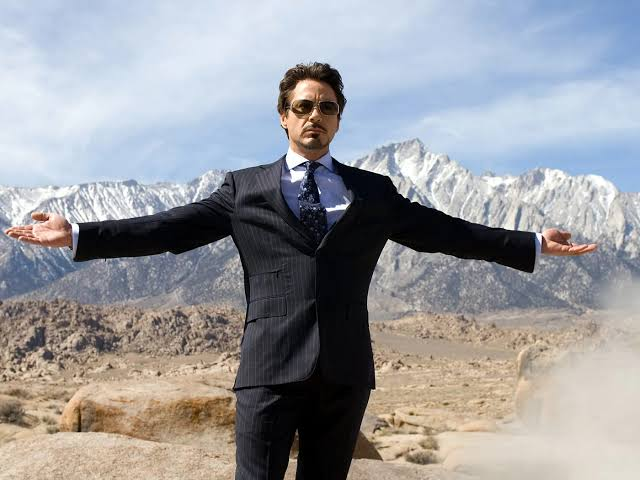

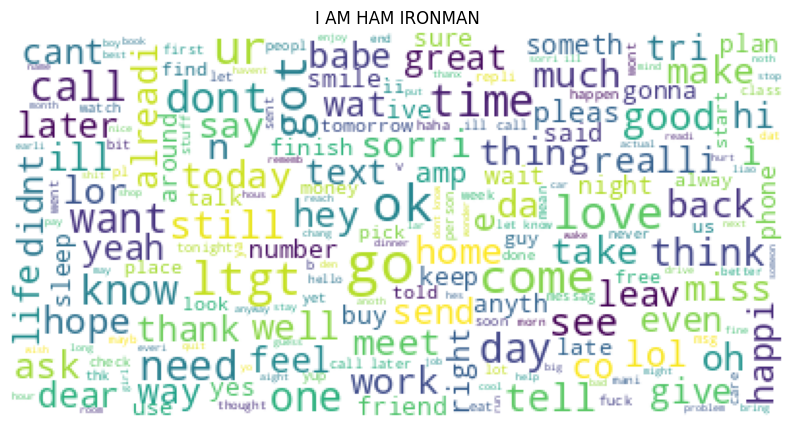

In [ ]:
twitter_mask=np.array(Image.open('/home/me.jpg').convert('L'))
wc=WordCloud(
    background_color='white',
    max_words=1000,
    mask=twitter_mask,
    max_font_size=30,
)
wc.generate(' '.join(text for text in df.loc[df['label']=='ham','message_clean']))
plt.figure(figsize=(10,10))
plt.title("I AM HAM IRONMAN")
plt.imshow(wc)
plt.axis('off')

(np.float64(-0.5), np.float64(576.5), np.float64(432.5), np.float64(-0.5))

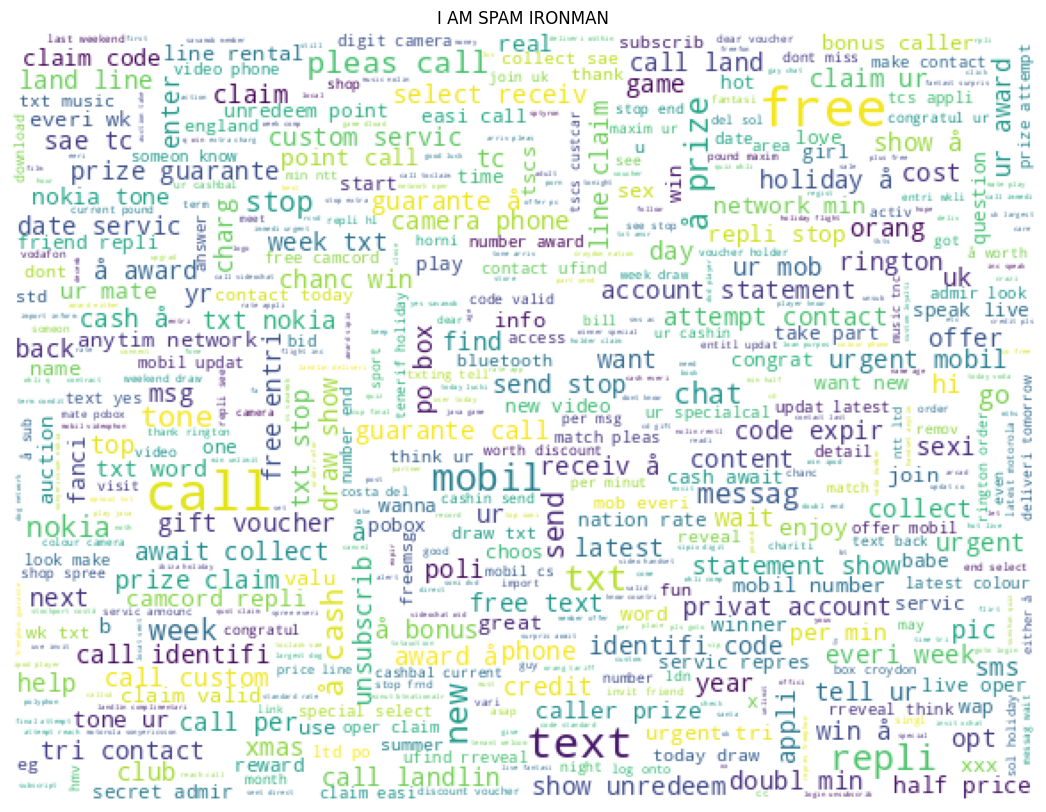

In [ ]:
twitter_mask=np.array(Image.open('/home/me-removebg-preview.png').convert('L'))
wc=WordCloud(
    background_color='white',
    max_words=1000,
    mask=twitter_mask,
    max_font_size=30,
)
wc.generate(' '.join(text for text in df.loc[df['label']=='spam','message_clean']))
plt.figure(figsize=(18,10))
plt.title("I AM SPAM IRONMAN")
plt.imshow(wc)
plt.axis('off')

In [ ]:
x=df['message_clean']
y=df['target_encoded']

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42)
print(len(x_train),len(y_train))
print(len(x_test),len(y_test))

4179 4179
1393 1393


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
vect=CountVectorizer()
vect.fit(x_train)


CountVectorizer()

In [ ]:
x_train_dtm=vect.transform(x_train)
x_test_dtm=vect.transform(x_test)